# 29 April 2026
- checking full galaxy sample of CVs
- converting to blip readable format

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'  # LSS to avoid OOM errors when using jax in this script
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import legwork as lw
import astropy.coordinates as cc
import astropy.units as u
import healpy as hp
import sys
sys.path.append('../scripts/')
import paths
from scipy import stats, interpolate


In [7]:
colnams = ['f_gw[Hz]', 'Mchirp[Msun]', 'x_galcent[kpc]', 'y_galcent[kpc]', 'z_galcent[kpc]', 'inclination[rad]']
pd.read_csv(paths.lssdata/'dat_fullgxy_emgap_rs150914_nsamp1.0e+06_final.txt')

,# f_gw[Hz],Mchirp[Msun],x_galcent[kpc],y_galcent[kpc],z_galcent[kpc],inclination[rad]
0,0.000195,0.313483,3.757470,3.758821,-1.588844,1.423749
1,0.000215,0.312769,0.060317,-2.079253,-1.068281,1.176779
2,0.000189,0.314349,-4.662948,1.469362,-0.343720,0.746262
3,0.000228,0.314585,-0.042451,-10.576348,-0.163817,1.049088
4,0.000193,0.314575,-6.333223,6.077986,-1.128986,0.520356
...,...,...,...,...,...,...
255799,0.000259,0.313750,-4.421932,-2.734742,0.269164,1.306432
255800,0.000210,0.313808,1.558002,-2.605291,-0.108411,0.863512
255801,0.000190,0.313856,0.806129,3.026761,-0.557221,1.433608
255802,0.000192,0.312140,-0.027401,-2.507071,-0.748234,0.414285


In [2]:
# def convert_popsynth_to_blipreadable(input_loc, output_loc):
#     """ Converts population file to blip readable format with columns f, h, lat, long.

#     Parameters
#     ----------
#     input_loc : str
#         Location of the input file containing the population synthesis data.
#     output_name : str
#         Name of the output file to save the converted data in blip readable format.
#     """
#     file = input_loc
#     binaries = pd.read_csv(file)
#     blip_columns = ['f','h','lat','long']
#     xG, yG, zG = binaries[' x_galcent[kpc]'].to_numpy(), binaries[' y_galcent[kpc]'].to_numpy(), binaries[' z_galcent[kpc]'].to_numpy()
#     ## convert to distances and lat/long ecliptic coords
#     gc = cc.SkyCoord(x=xG*u.kpc,y=yG*u.kpc,z=zG*u.kpc, frame='galactocentric')
#     SSBc = gc.transform_to(cc.BarycentricMeanEcliptic)

#     ## get latitude, longitude
#     lat = SSBc.lat.to(u.rad).value
#     long = SSBc.lon.to(u.rad).value

#     ## making sure we've handled our coordinate transforms correctly
#     dist = SSBc.distance.to(u.kpc)
#     mc = lw.utils.chirp_mass(binaries['# m1[Msun]'],binaries[' m2[Msun]']).to_numpy()*u.Msun
#     fs = binaries[' f_gw[Hz]'].to_numpy()
#     f_orb = fs*u.Hz/2
#     ## assuming circular binaries
#     ecc = np.zeros(len(f_orb))

#     hs = lw.strain.h_0_n(mc,f_orb,ecc,2,dist)

#     blip_df = pd.DataFrame(data=np.vstack((fs,hs.flatten(),lat,long)).T,columns=blip_columns)

#     blip_df.to_csv(output_loc, index=False,sep=' ',header=False)


In [10]:
cvgxyfile = paths.lssdata / 'dat_fullgxy_emgap_combined_rs150914_nsamp1.0e+06_BLIP_final.txt'
cvgxy = pd.read_csv(cvgxyfile, header=None, delim_whitespace=True, names=['f', 'h', 'lat', 'long'])
print(cvgxy.columns)


/tmp/ipykernel_3841589/3485801547.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  cvgxy = pd.read_csv(cvgxyfile, header=None, delim_whitespace=True, names=['f', 'h', 'lat', 'long'])


Index(['f', 'h', 'lat', 'long'], dtype='object')


In [11]:
cvgxy

,f,h,lat,long
0,0.000106,8.285939e-24,-0.327583,4.475028
1,0.000410,2.073834e-24,-0.021720,4.644512
2,0.000328,3.006875e-24,-0.029584,4.717606
3,0.000373,5.448895e-24,-0.433543,4.351737
4,0.000379,3.213722e-24,-0.281714,4.552183
...,...,...,...,...
2594161,0.000259,1.357999e-23,-0.596101,4.227292
2594162,0.000210,5.437444e-24,-0.328284,4.529290
2594163,0.000190,5.383982e-24,0.156536,4.872486
2594164,0.000192,5.965321e-24,-0.400190,4.580084


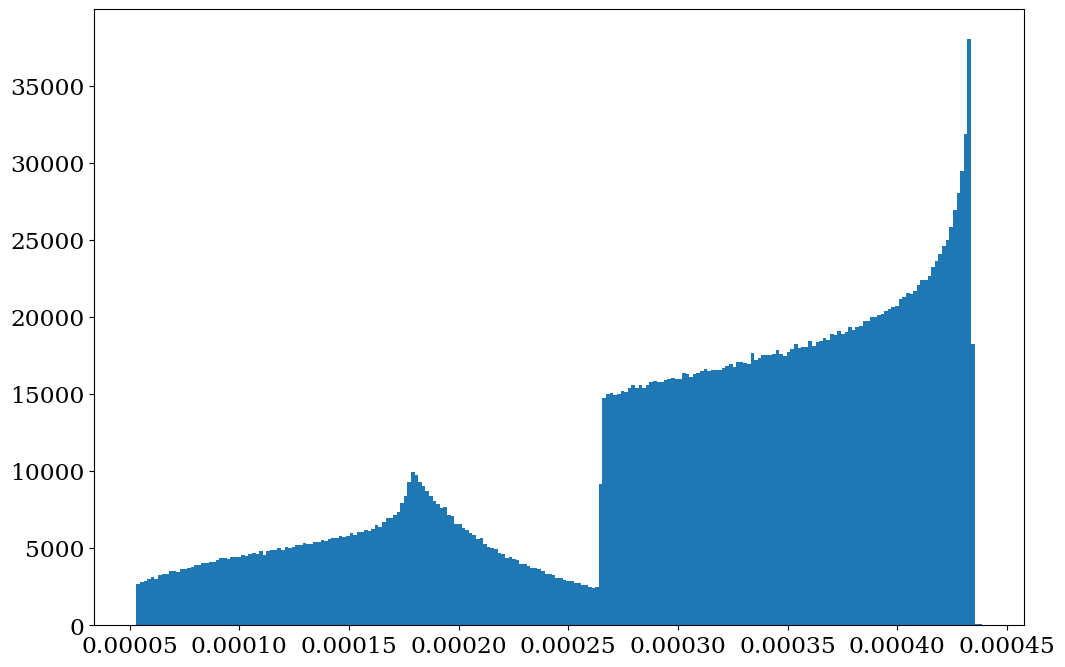

In [13]:
plt.hist(cvgxy['f'], bins=234);

<Figure size 1200x800 with 0 Axes>

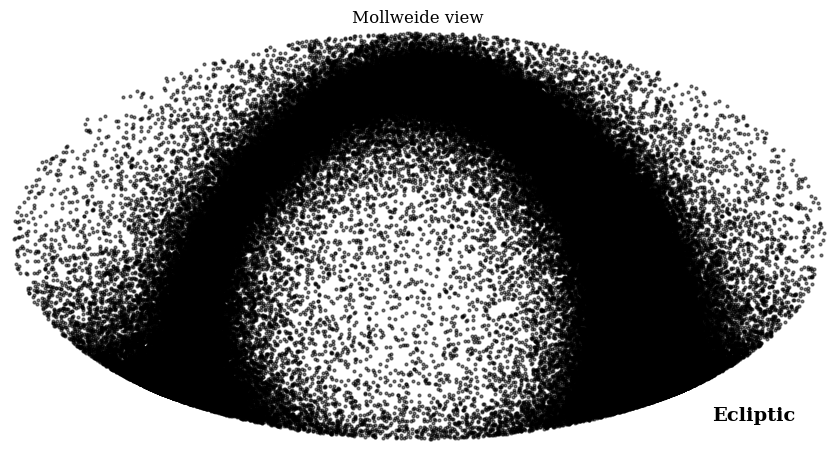

In [14]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(cvgxy['long']*u.rad.to(u.deg),cvgxy['lat']*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

[]

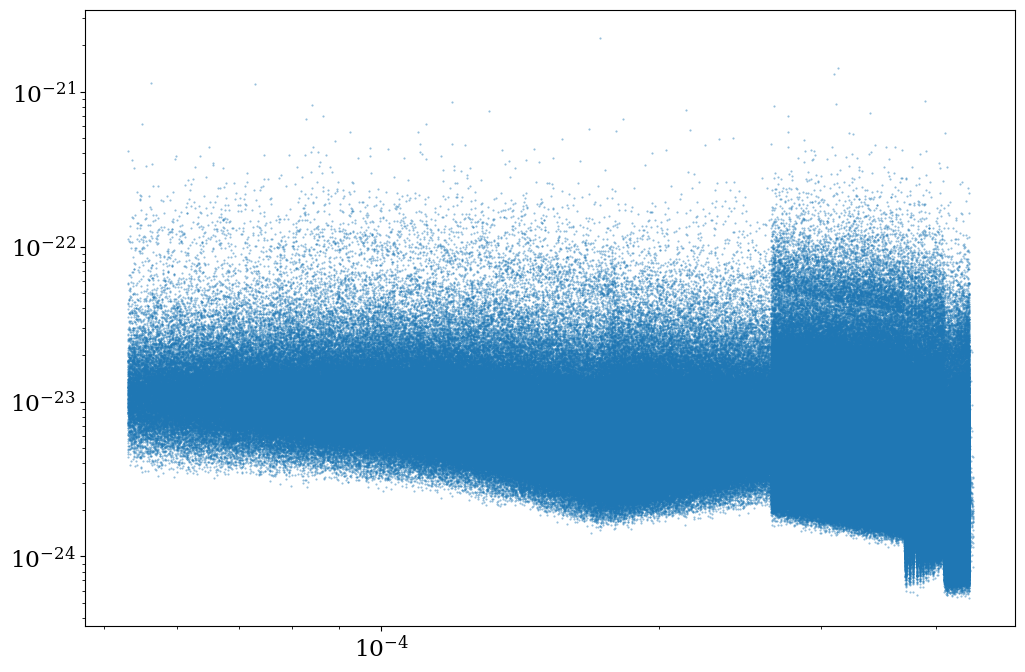

In [ ]:
plt.plot(cvgxy['f'], cv, '.', markersize=1, alpha=0.5)
plt.loglog()

In [7]:
input_name = 'dat_fullgxy_rs42_final.txt'
output_name = input_name.split('.')[0]+'_blip.txt'
convert_popsynth_to_blipreadable(input_name, output_name)

NameError: name 'convert_popsynth_to_blipreadable' is not defined

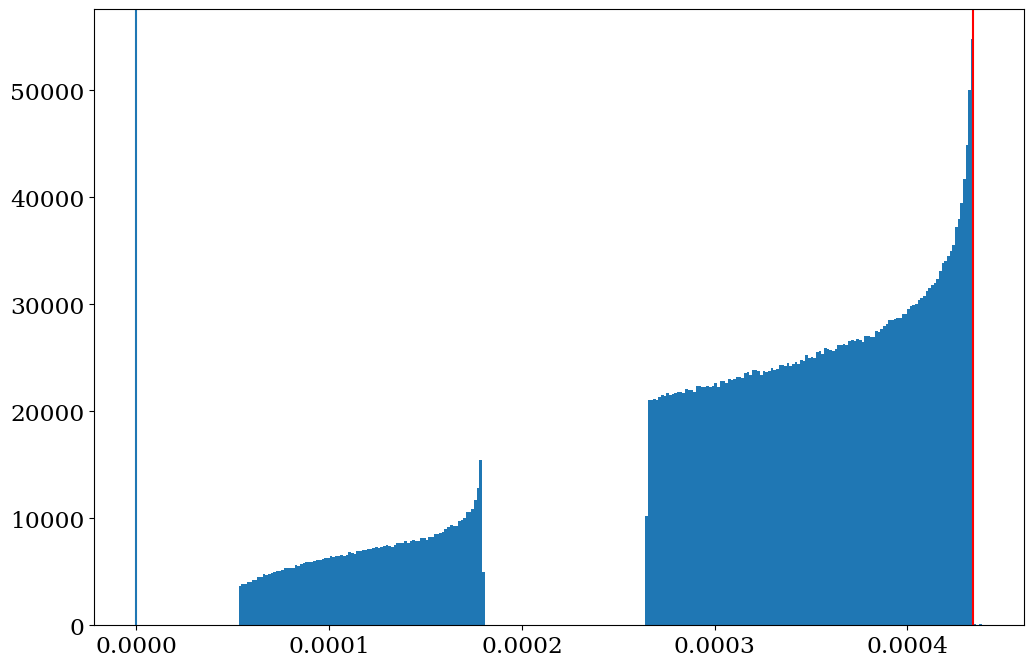

In [13]:
cvcts, fbins, _ = plt.hist(cvgxy[' f_gw[Hz]'], bins='auto')
minPorb = 76.78 #min
maxfgw = (minPorb*60)**(-1)*2
plt.axvline(maxfgw, color='red', label='Max f_gw for') 
#plt.xlim(3.9e-4, 4.5e-4)
plt.axvline()

In [14]:
edgects = -1 # LSS get us started
cvcts, fbins = np.histogram(cvgxy[' f_gw[Hz]'], bins='auto')
nbns = len(fbins)-1
print(len(fbins), nbns)
while edgects < 0:
    cvcts, fbins = np.histogram(cvgxy[' f_gw[Hz]'], bins=nbns)
    emgapinds = np.where(cvcts == 0)[0]
    edgects = cvcts[emgapinds[0]-1] - cvcts[emgapinds[0]-2]
    if edgects < 0:
        print('Edge effects found! removing 1 bin')
        nbns -= 1

print('Final number of bins:', nbns)

279 278
Edge effects found! removing 1 bin
Final number of bins: 277


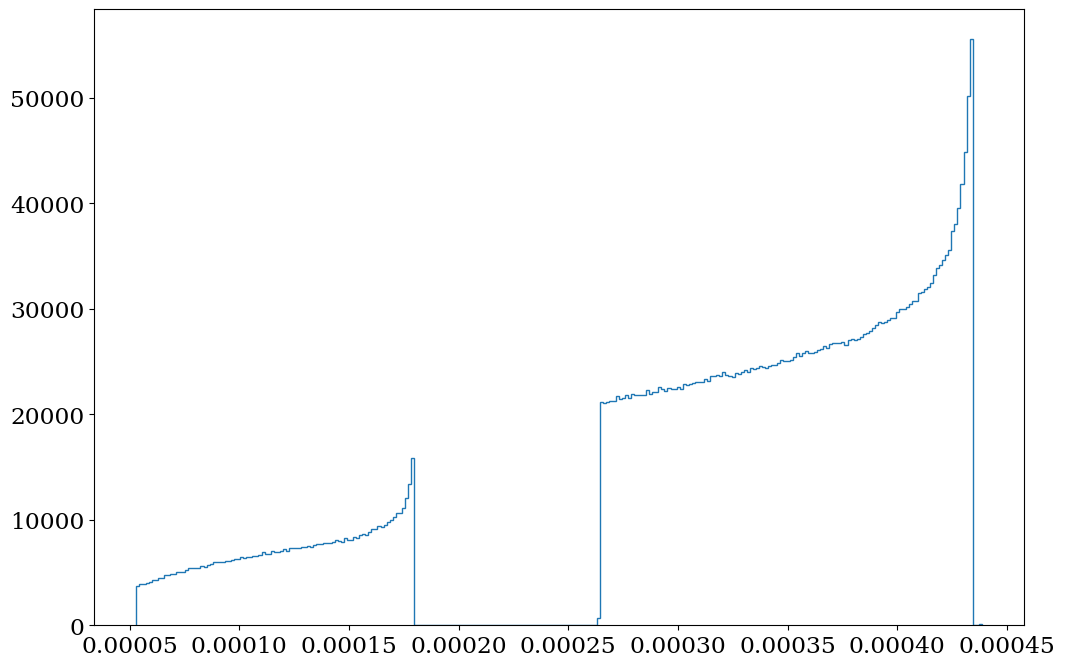

In [15]:
plt.stairs(cvcts, fbins)

In [18]:
len(emgapinds)

60

In [16]:
emgapinds = np.where(cvcts == 0)[0]
edgects = cvcts[emgapinds[0]-1] - cvcts[emgapinds[0]-2]
if edgects < 0:
    print('Edge effects found! removing 1 bin')

ValueError: too many values to unpack (expected 2)

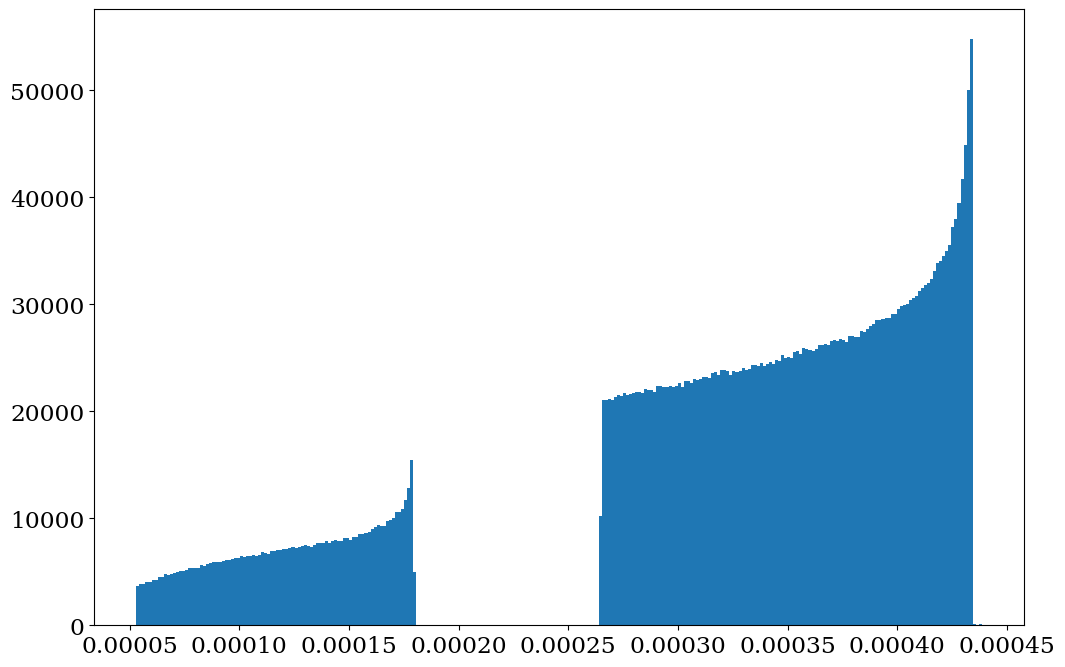

In [28]:
cvcts2, fbins2 = plt.hist(cvgxy[' f_gw[Hz]'], bins=len(fbins)-1)

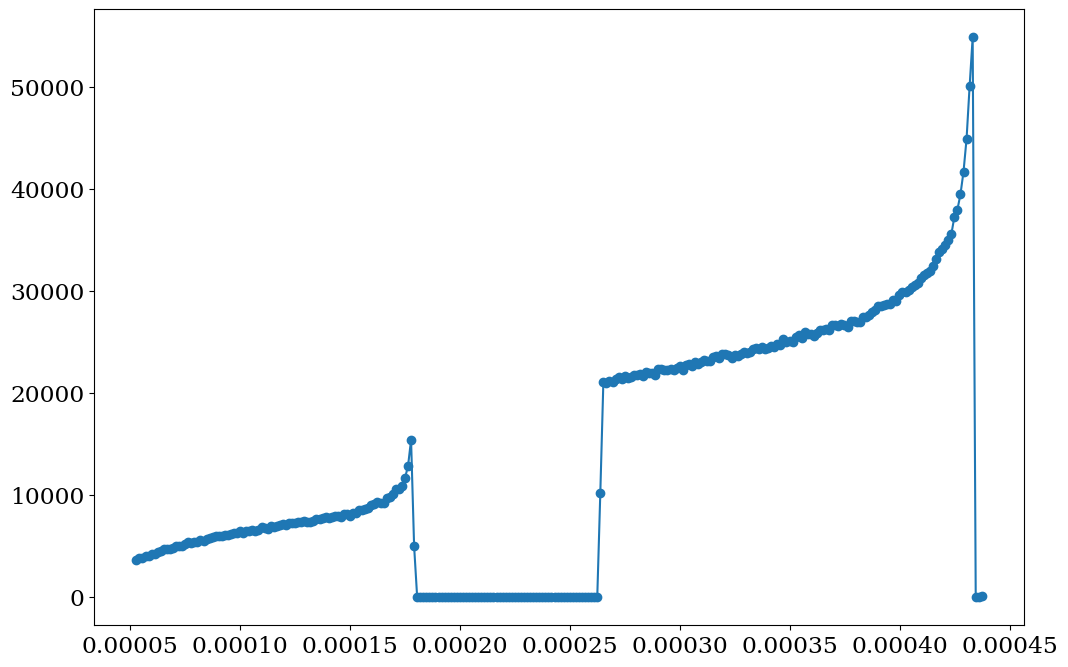

In [23]:
plt.plot(fbins2[:-1], cvcts2, marker='o')

<BarContainer object of 278 artists>

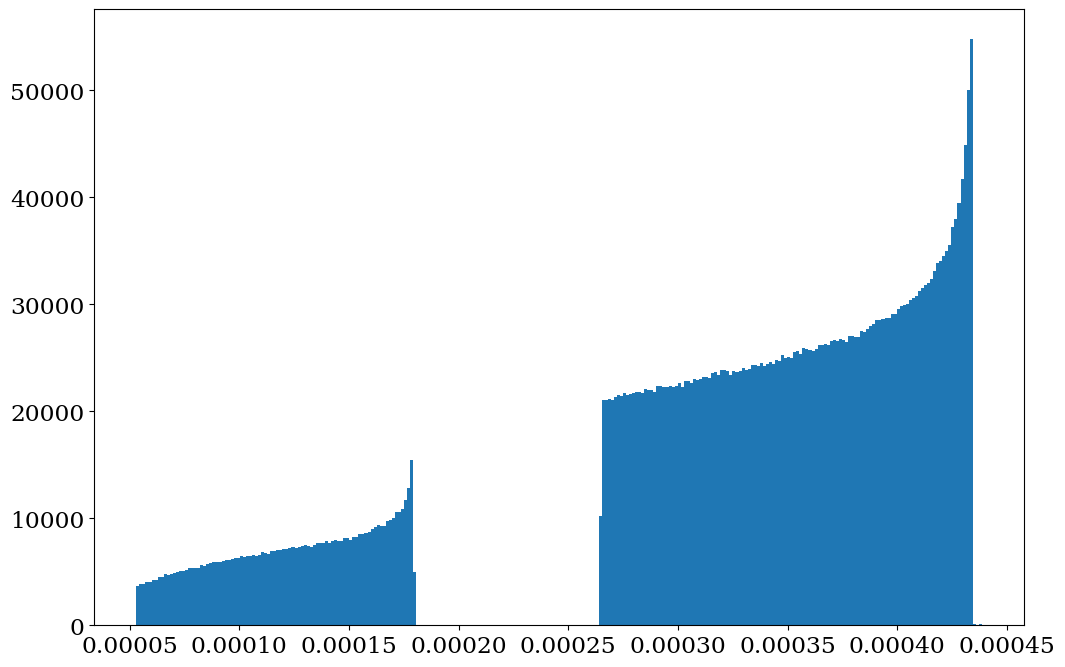

In [16]:
plt.bar(fbins[:-1], cvcts, width=np.diff(fbins), align='edge')

(array([ 3691.,  3893.,  3898.,  4034.,  4079.,  4256.,  4292.,  4479.,
         4505.,  4779.,  4722.,  4818.,  4893.,  5026.,  5032.,  5091.,
         5223.,  5387.,  5427.,  5389.,  5443.,  5602.,  5569.,  5742.,
         5857.,  5988.,  5963.,  6025.,  5998.,  6139.,  6114.,  6191.,
         6318.,  6303.,  6513.,  6393.,  6470.,  6511.,  6571.,  6583.,
         6667.,  6926.,  6784.,  6794.,  7011.,  6942.,  6992.,  7065.,
         7232.,  7086.,  7321.,  7317.,  7324.,  7363.,  7467.,  7389.,
         7501.,  7401.,  7575.,  7677.,  7697.,  7789.,  7847.,  7786.,
         7854.,  8065.,  7991.,  7862.,  8245.,  8118.,  8063.,  8361.,
         8321.,  8590.,  8655.,  8555.,  8855.,  9113.,  9121.,  9374.,
         9323.,  9467.,  9780., 10000., 10246., 10664., 10691., 11112.,
        12050., 13410., 15836.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0., 

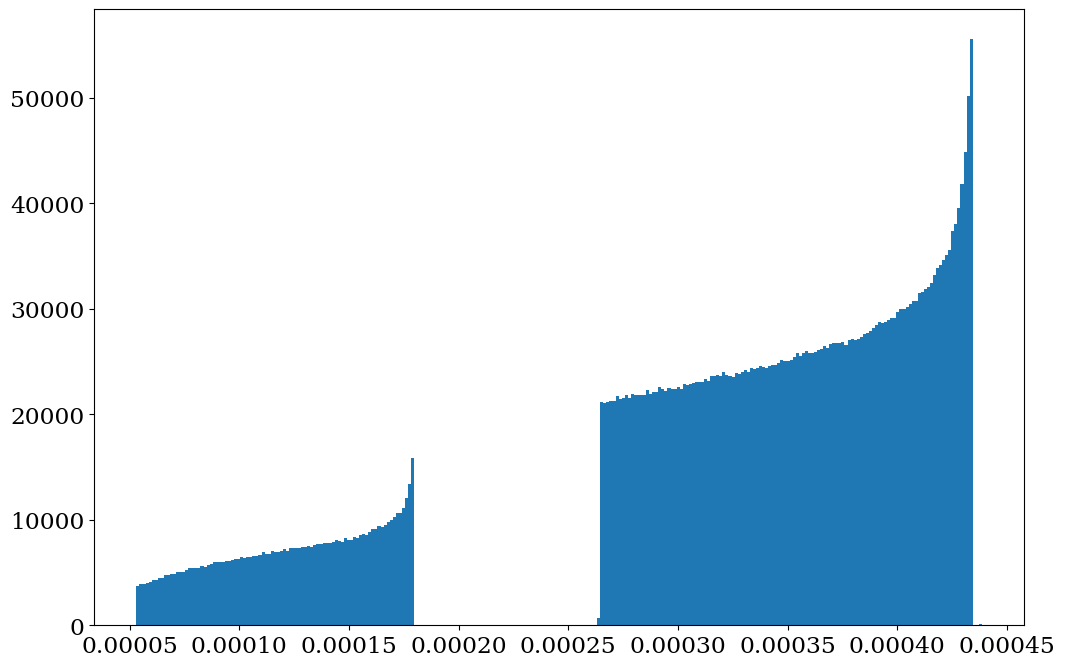

In [8]:
plt.hist(cvgxy[' f_gw[Hz]'], bins=277)

In [7]:
c_galcent = cc.SkyCoord(x=cvgxy[' x_galcent[kpc]'].values*u.kpc,y=cvgxy[' y_galcent[kpc]'].values*u.kpc,z=cvgxy[' z_galcent[kpc]'].values*u.kpc, frame='galactocentric', representation_type='cartesian')
c_ecl = c_galcent.transform_to(cc.BarycentricMeanEcliptic)
## get latitude, longitude
lat = c_ecl.lat.to(u.rad).value
long = c_ecl.lon.to(u.rad).value

<Figure size 1200x800 with 0 Axes>

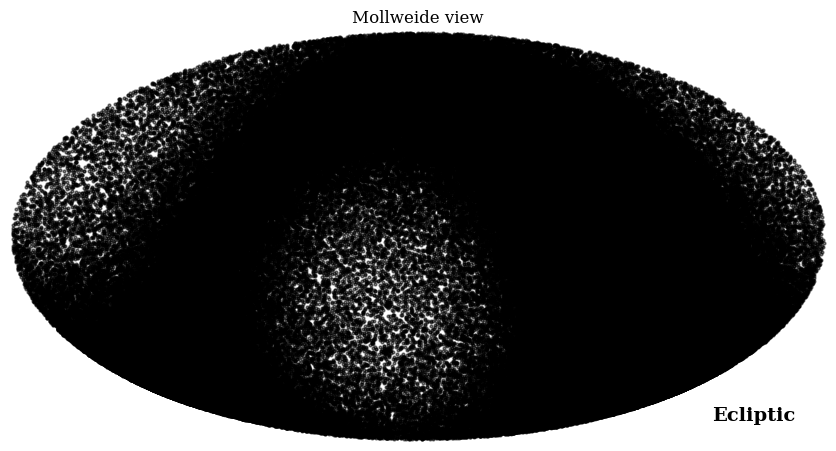

In [8]:
## check
plt.figure()
hp.mollview(coord='E')
hp.projscatter(long*u.rad.to(u.deg),lat*u.rad.to(u.deg),lonlat=True,color='k',alpha=0.5,s=4)
plt.show()

In [15]:
dwdthiele = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/thiele_fiducial_thin_mcmillan_galaxy.txt', delim_whitespace=True, names=['f','h','lat','long'])

/tmp/ipykernel_310461/946873003.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dwdthiele = pd.read_csv('/home/levis/lisa_projects/blip_CVs/datasets/dwd_datasets/thiele_fiducial_thin_mcmillan_galaxy.txt', delim_whitespace=True, names=['f','h','lat','long'])


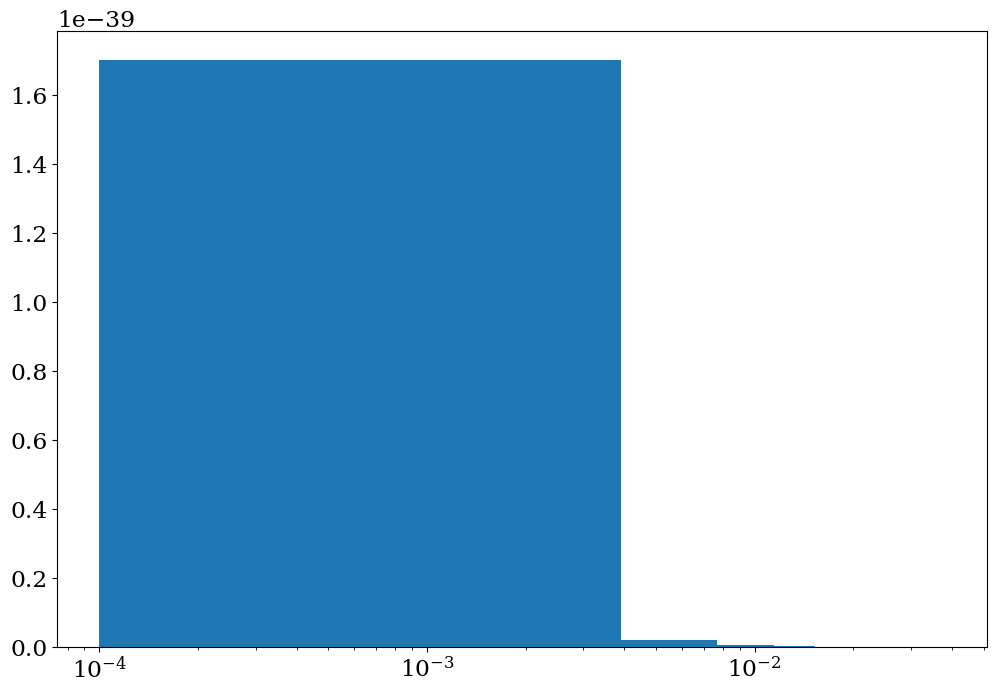

In [20]:
plt.hist(dwdthiele['f'], weights=dwdthiele['h']**2)
plt.xscale('log')